In [1]:
# =========================
# 1. Import thư viện
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)

# =========================
# 2. Cấu hình đường dẫn
# =========================

file_path = "../data/processed/features_final.csv"
label_col = "label"

fig_dir = Path("../output/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 3. Đọc dữ liệu
# =========================

df = pd.read_csv(file_path)

print("Số lượng mẫu:", len(df))
print("Các cột dữ liệu:")
print(df.columns.tolist())

Số lượng mẫu: 835
Các cột dữ liệu:
['channel_id', 'title', 'label', 'time_interval_std', 'upload_burst_ratio', 'video_upload_frequency', 'view_per_video', 'dash_density', 'title_length_std', 'capitalization_ratio', 'opening_repeat_ratio', 'temporal_clickbait_ratio', 'type_token_ratio', 'avg_title_similarity', 'sub_to_view_ratio', 'subscriber_velocity', 'sub_to_view_velocity_ratio', 'subscriber_count', 'view_count', 'video_count', 'n_videos_crawled']


In [2]:
# =========================
# 4. Mã hóa label
# =========================

if df[label_col].dtype == "object":
    df[label_col] = df[label_col].map({
        "genuine": 0,
        "slop": 1
    })

print("Phân phối label sau mã hóa:")
print(df[label_col].value_counts())

# =========================
# 5. Chuẩn bị dữ liệu model
# =========================

feature_cols = df.drop(columns=[label_col]).select_dtypes(include=[np.number]).columns.tolist()

X = df[feature_cols]
y = df[label_col]

print("Số feature:", len(feature_cols))
print(feature_cols)

# =========================
# 6. Chia tập train/test
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# =========================
# 7. Train Random Forest
# =========================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

# =========================
# 8. Dự đoán trên tập test
# =========================

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred,
    target_names=["genuine", "slop"]
))

Phân phối label sau mã hóa:
label
0    476
1    359
Name: count, dtype: int64
Số feature: 18
['time_interval_std', 'upload_burst_ratio', 'video_upload_frequency', 'view_per_video', 'dash_density', 'title_length_std', 'capitalization_ratio', 'opening_repeat_ratio', 'temporal_clickbait_ratio', 'type_token_ratio', 'avg_title_similarity', 'sub_to_view_ratio', 'subscriber_velocity', 'sub_to_view_velocity_ratio', 'subscriber_count', 'view_count', 'video_count', 'n_videos_crawled']
Train size: 668
Test size: 167
              precision    recall  f1-score   support

     genuine       0.94      0.89      0.92        95
        slop       0.87      0.93      0.90        72

    accuracy                           0.91       167
   macro avg       0.91      0.91      0.91       167
weighted avg       0.91      0.91      0.91       167



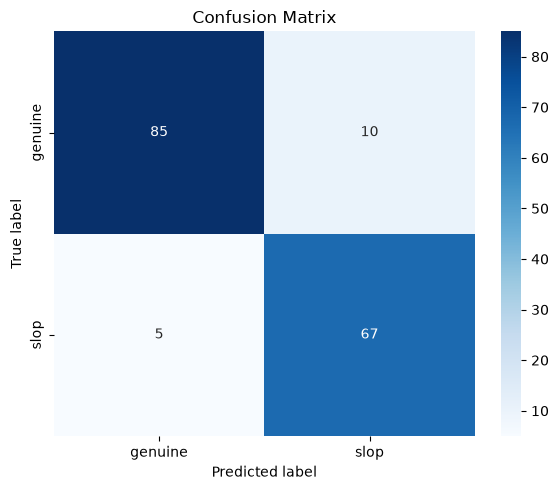

In [3]:
# =========================
# 9. Vẽ confusion matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["genuine", "slop"],
    yticklabels=["genuine", "slop"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig(fig_dir / "07_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

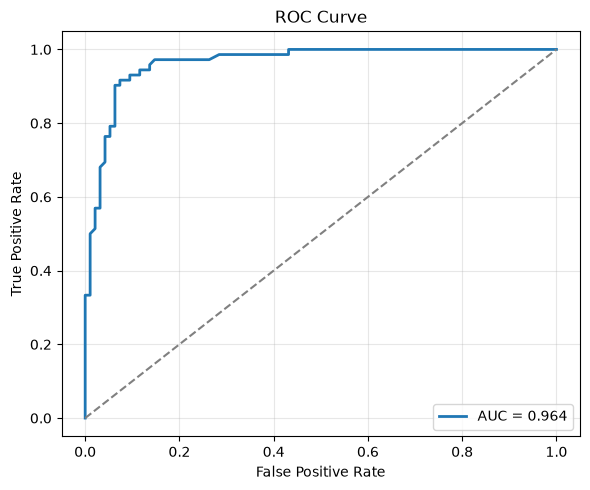

In [4]:
# =========================
# 10. Vẽ ROC curve với AUC
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "08_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

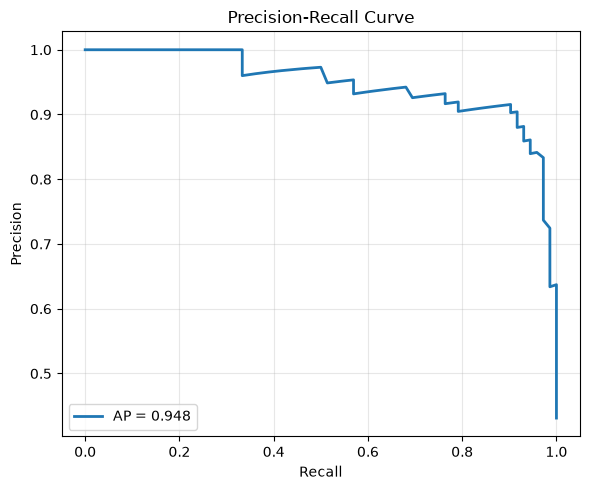

In [5]:
# =========================
# 11. Vẽ Precision-Recall curve
# =========================

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {avg_precision:.3f}", linewidth=2)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "09_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# =========================
# 12. Tạo dataframe phân tích lỗi
# =========================

error_df = X_test.copy()
error_df["true_label"] = y_test.values
error_df["pred_label"] = y_pred
error_df["pred_proba_slop"] = y_proba

error_df["true_name"] = error_df["true_label"].map({
    0: "genuine",
    1: "slop"
})

error_df["pred_name"] = error_df["pred_label"].map({
    0: "genuine",
    1: "slop"
})

wrong_df = error_df[error_df["true_label"] != error_df["pred_label"]]

print("Số mẫu dự đoán sai:", len(wrong_df))
display(wrong_df.head())

Số mẫu dự đoán sai: 15


,time_interval_std,upload_burst_ratio,video_upload_frequency,view_per_video,dash_density,title_length_std,capitalization_ratio,opening_repeat_ratio,temporal_clickbait_ratio,type_token_ratio,...,sub_to_view_velocity_ratio,subscriber_count,view_count,video_count,n_videos_crawled,true_label,pred_label,pred_proba_slop,true_name,pred_name
523,34.037240,0.050000,0.125552,1543.219512,0.000000,16.499851,0.050202,0.02439,0.019491,0.465839,...,-1.854273,563,63272,41,41,0,1,0.846667,genuine,slop
454,0.111148,0.000000,2.795675,42832.006366,0.000000,9.566797,0.202711,0.28000,0.575981,0.571759,...,-2.157589,983000,141302789,3299,50,1,0,0.180000,slop,genuine
276,0.279974,0.142857,0.994010,25883.408163,0.007342,4.402000,0.164667,0.10000,0.328132,0.289474,...,-2.380991,10500,2536574,98,50,0,1,0.963333,genuine,slop
526,0.754694,0.000000,0.143564,5987.500000,0.000000,16.872685,0.067732,0.00000,0.284950,0.680000,...,-1.684449,468,23950,4,4,0,1,0.920000,genuine,slop
37,26.231928,0.100000,0.080134,108691.090909,0.007299,13.218444,0.290401,0.00000,0.010015,0.542254,...,-1.546960,33800,1195602,11,11,1,0,0.390000,slop,genuine


In [7]:
# =========================
# 13. Lọc False Positive và False Negative
# =========================

false_positive = error_df[
    (error_df["true_label"] == 0) &
    (error_df["pred_label"] == 1)
]

false_negative = error_df[
    (error_df["true_label"] == 1) &
    (error_df["pred_label"] == 0)
]

print("False Positive:", len(false_positive))
print("False Negative:", len(false_negative))

print("\nBảng lỗi:")
display(pd.crosstab(wrong_df["true_name"], wrong_df["pred_name"]))

print("\nMột vài mẫu False Positive:")
display(false_positive.head())

print("\nMột vài mẫu False Negative:")
display(false_negative.head())

False Positive: 10
False Negative: 5

Bảng lỗi:


pred_name,genuine,slop
true_name,,
genuine,0,10
slop,5,0



Một vài mẫu False Positive:


,time_interval_std,upload_burst_ratio,video_upload_frequency,view_per_video,dash_density,title_length_std,capitalization_ratio,opening_repeat_ratio,temporal_clickbait_ratio,type_token_ratio,...,sub_to_view_velocity_ratio,subscriber_count,view_count,video_count,n_videos_crawled,true_label,pred_label,pred_proba_slop,true_name,pred_name
523,34.037240,0.050000,0.125552,1543.219512,0.000000,16.499851,0.050202,0.02439,0.019491,0.465839,...,-1.854273,563,63272,41,41,0,1,0.846667,genuine,slop
276,0.279974,0.142857,0.994010,25883.408163,0.007342,4.402000,0.164667,0.10000,0.328132,0.289474,...,-2.380991,10500,2536574,98,50,0,1,0.963333,genuine,slop
526,0.754694,0.000000,0.143564,5987.500000,0.000000,16.872685,0.067732,0.00000,0.284950,0.680000,...,-1.684449,468,23950,4,4,0,1,0.920000,genuine,slop
331,16.597690,0.000000,0.053571,1974.857143,0.000000,19.485212,0.083254,0.00000,0.024354,0.884058,...,-1.665192,171,13824,7,7,0,1,0.546667,genuine,slop
552,2.867390,0.163265,0.174745,979.032967,0.000000,15.115872,0.209864,0.10000,0.129286,0.532588,...,-2.279302,652,178184,182,50,0,1,0.533333,genuine,slop



Một vài mẫu False Negative:


,time_interval_std,upload_burst_ratio,video_upload_frequency,view_per_video,dash_density,title_length_std,capitalization_ratio,opening_repeat_ratio,temporal_clickbait_ratio,type_token_ratio,...,sub_to_view_velocity_ratio,subscriber_count,view_count,video_count,n_videos_crawled,true_label,pred_label,pred_proba_slop,true_name,pred_name
454,0.111148,0.000000,2.795675,42832.006366,0.000000,9.566797,0.202711,0.28,0.575981,0.571759,...,-2.157589,983000,141302789,3299,50,1,0,0.180000,slop,genuine
37,26.231928,0.100000,0.080134,108691.090909,0.007299,13.218444,0.290401,0.00,0.010015,0.542254,...,-1.546960,33800,1195602,11,11,1,0,0.390000,slop,genuine
385,0.302994,0.061224,2.836823,5160.885082,0.000000,24.604585,0.092436,0.12,0.199541,0.537349,...,-2.447039,184000,51510794,9981,50,1,0,0.370000,slop,genuine
354,28.845866,0.244898,0.102463,334950.031746,0.015075,15.157256,0.268501,0.16,0.010052,0.390110,...,-1.939640,242000,21101852,63,50,1,0,0.070000,slop,genuine
445,6.110297,0.061224,0.194103,913169.193182,0.000000,5.596284,0.139633,0.84,0.047818,0.368876,...,-2.574099,214000,80358889,88,50,1,0,0.496667,slop,genuine


In [8]:
# =========================
# 14. Lấy top feature quan trọng để phân tích lỗi
# =========================

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

top_features = importance_df.head(6)["feature"].tolist()

print("Top 6 features dùng để phân tích lỗi:")
print(top_features)

Top 6 features dùng để phân tích lỗi:
['subscriber_count', 'view_count', 'view_per_video', 'subscriber_velocity', 'avg_title_similarity', 'time_interval_std']


In [9]:
# =========================
# 15. Chọn các cột để so sánh đặc điểm lỗi
# =========================

extra_cols = [
    "subscriber",
    "subscribers",
    "subscriber_count",
    "view_count",
    "views",
    "video_count",
    "upload_count",
    "post_frequency",
    "posting_frequency",
    "avg_views",
    "avg_likes",
    "avg_comments"
]

compare_cols = top_features.copy()

for col in extra_cols:
    if col in error_df.columns and col not in compare_cols:
        compare_cols.append(col)

print("Các cột dùng để so sánh lỗi:")
print(compare_cols)

Các cột dùng để so sánh lỗi:
['subscriber_count', 'view_count', 'view_per_video', 'subscriber_velocity', 'avg_title_similarity', 'time_interval_std', 'video_count']


In [10]:
# =========================
# 16. Gắn nhãn loại lỗi
# =========================

plot_error_df = error_df.copy()
plot_error_df["error_type"] = "Correct"

plot_error_df.loc[
    (plot_error_df["true_label"] == 0) &
    (plot_error_df["pred_label"] == 1),
    "error_type"
] = "False Positive"

plot_error_df.loc[
    (plot_error_df["true_label"] == 1) &
    (plot_error_df["pred_label"] == 0),
    "error_type"
] = "False Negative"

print(plot_error_df["error_type"].value_counts())

error_type
Correct           152
False Positive     10
False Negative      5
Name: count, dtype: int64


In [11]:
# =========================
# 17. Bảng thống kê đặc điểm mẫu đúng/sai
# =========================

error_summary = plot_error_df.groupby("error_type")[compare_cols].mean(numeric_only=True)
display(error_summary)

,subscriber_count,view_count,view_per_video,subscriber_velocity,avg_title_similarity,time_interval_std,video_count
error_type,,,,,,,
Correct,1.091719e+06,4.347434e+08,615462.626533,15552.885257,0.065598,9.619872,776.723684
False Negative,3.313600e+05,5.909399e+07,280960.641457,13395.078249,0.074338,12.320447,2688.400000
False Positive,1.013990e+04,1.319602e+06,44535.825177,63.837551,0.066723,8.257824,86.000000


C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


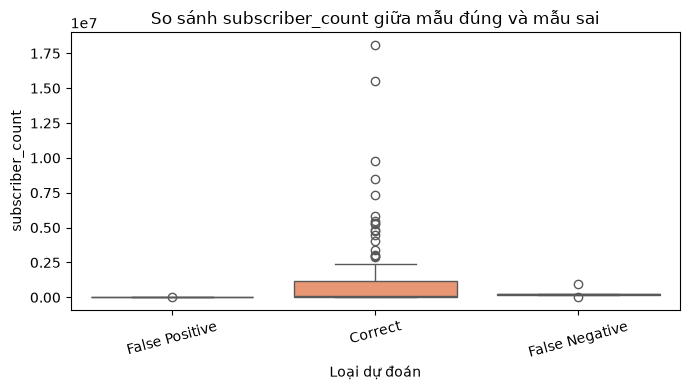

C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


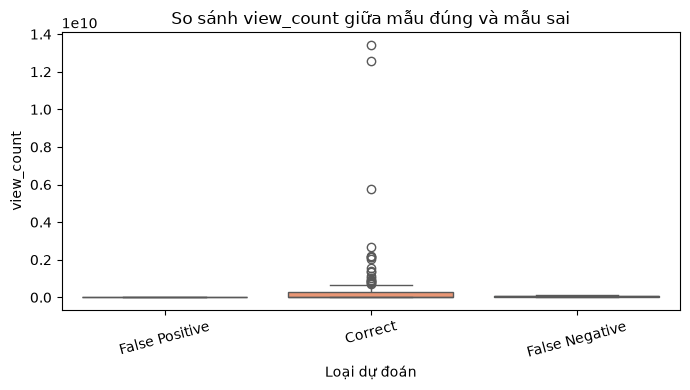

C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


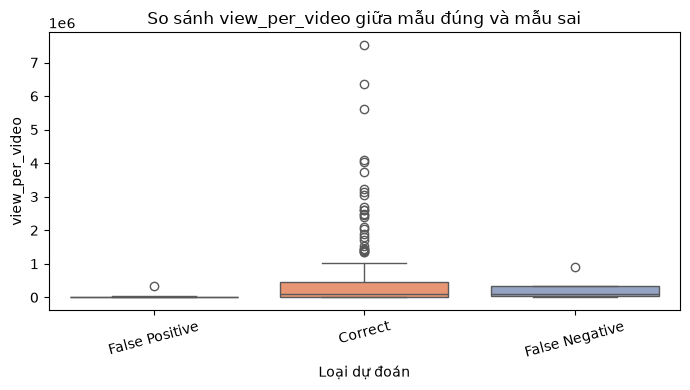

C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


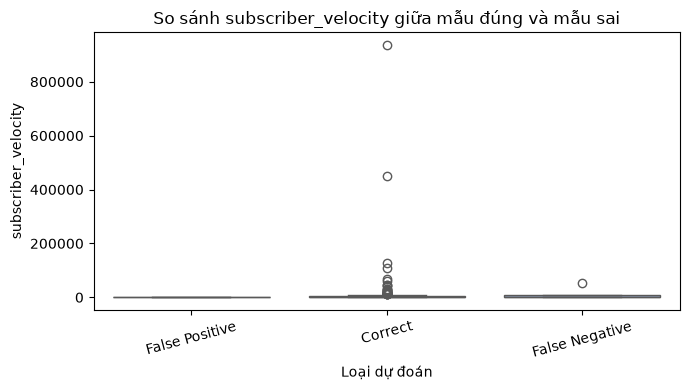

C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


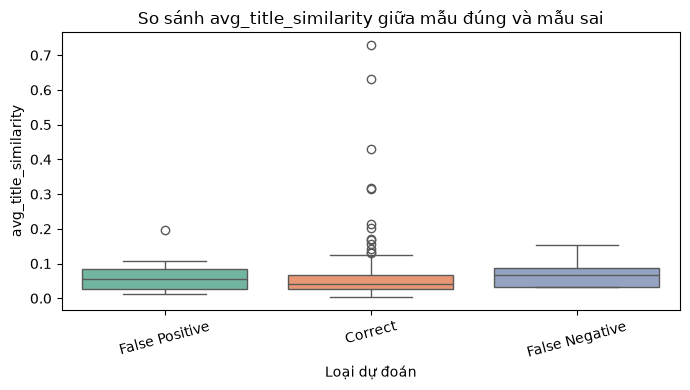

C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


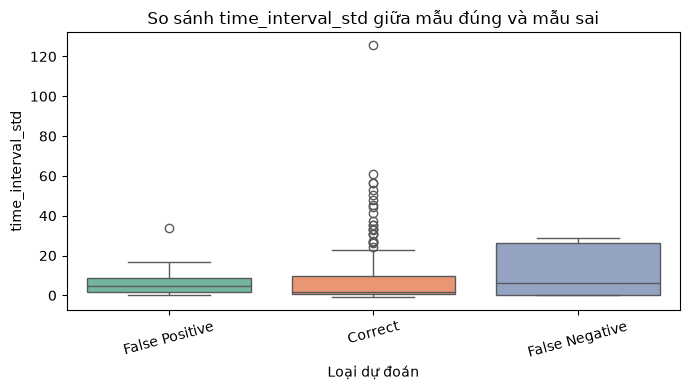

C:\Users\me\AppData\Local\Temp\ipykernel_4476\296788597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


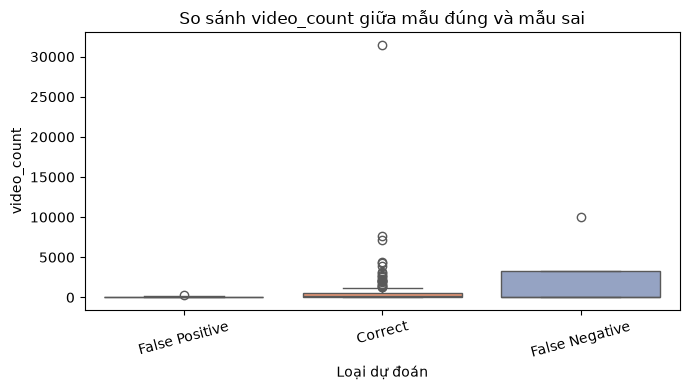

In [12]:
# =========================
# 18. Vẽ boxplot so sánh mẫu đúng/sai
# =========================

for col in compare_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=plot_error_df,
        x="error_type",
        y=col,
        palette="Set2"
    )
    plt.title(f"So sánh {col} giữa mẫu đúng và mẫu sai")
    plt.xlabel("Loại dự đoán")
    plt.ylabel(col)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(fig_dir / f"10_error_analysis_{col}.png", dpi=300, bbox_inches="tight")
    plt.show()

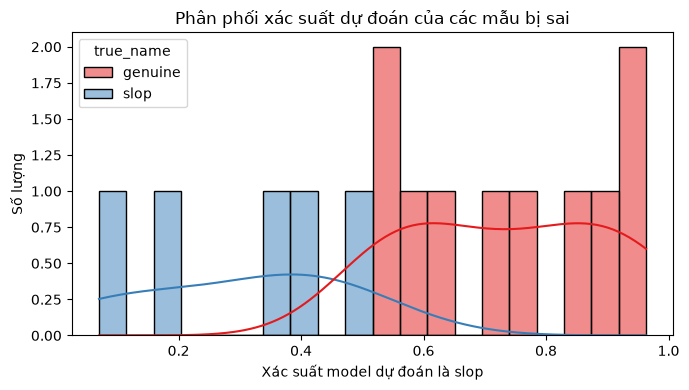

In [13]:
# =========================
# 19. Vẽ phân phối xác suất của các mẫu dự đoán sai
# =========================

plt.figure(figsize=(7, 4))
sns.histplot(
    data=wrong_df,
    x="pred_proba_slop",
    hue="true_name",
    bins=20,
    kde=True,
    palette="Set1"
)
plt.title("Phân phối xác suất dự đoán của các mẫu bị sai")
plt.xlabel("Xác suất model dự đoán là slop")
plt.ylabel("Số lượng")
plt.tight_layout()
plt.savefig(fig_dir / "11_wrong_prediction_probability.png", dpi=300, bbox_inches="tight")
plt.show()